In [1]:

from sklearn.datasets import fetch_california_housing
 
data = fetch_california_housing()
print(data.feature_names)
 
X, y = data.data, data.target

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [2]:
import torch.nn as nn
 
# Define the model
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

In [8]:
import torch.nn as nn
import torch.optim as optim
 
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [10]:
from sklearn.model_selection import train_test_split
import torch
# train-test split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)
 

In [5]:
!pip install tqdm
import copy
import numpy as np
import torch
import tqdm
 
# train-test split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)
 
# training parameters
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
# training loop
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
 
# restore model and return best accuracy
model.load_state_dict(best_weights)

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.47.1 requires cloudpickle, which is not installed.
shap 0.47.1 requires numba>=0.54, which is not installed.
shap 0.47.1 requires slicer==0.0.8, which is not installed.

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<All keys matched successfully>

MSE: 0.51
RMSE: 0.71


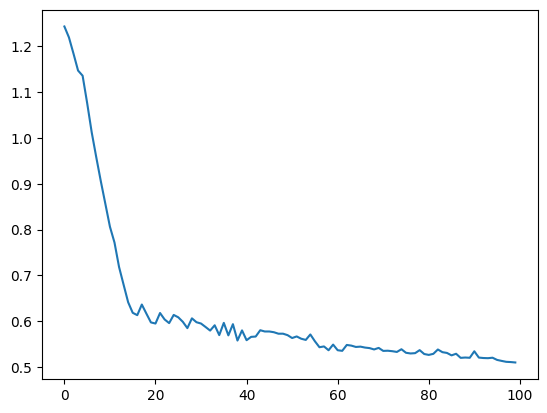

In [7]:
import matplotlib.pyplot as plt
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()

In [4]:
import sys
sys.path.append('../../utils/')


In [5]:
from Bias_Variance_Estimator import estimate_bias_variance

In [11]:
estimate_bias_variance(
    model_class=model,  # or any nn.Module class
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    num_models=30,
    epochs=20,
    model_kwargs = {}
    
)


Training on first resample


E:\Dissertation_bv\regression\MSE\../../utils\Bias_Variance_Estimator.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train_resampled,dtype = torch.float32).to(device)
E:\Dissertation_bv\regression\MSE\../../utils\Bias_Variance_Estimator.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train_resampled,dtype = torch.float32).view(-1,1).to(device)
E:\Dissertation_bv\regression\MSE\../../utils\Bias_Variance_Estimator.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  

epoch 0 loss 1.6492565870285034
epoch 1 loss 1.355078935623169
epoch 2 loss 1.0050303936004639
epoch 3 loss 0.9550490975379944
epoch 4 loss 1.1171786785125732
epoch 5 loss 0.8660485148429871
epoch 6 loss 0.7900977730751038
epoch 7 loss 0.3857317268848419
epoch 8 loss 0.7411564588546753
epoch 9 loss 0.35329803824424744
epoch 10 loss 0.8329182267189026
epoch 11 loss 0.5256075263023376
epoch 12 loss 0.8025577068328857
epoch 13 loss 0.8278770446777344
epoch 14 loss 0.4746187627315521
epoch 15 loss 0.935645580291748
epoch 16 loss 1.0830237865447998
epoch 17 loss 0.5262802839279175
epoch 18 loss 0.6243900656700134
epoch 19 loss 0.7285857796669006
Training on first resample
epoch 0 loss 0.9667618274688721
epoch 1 loss 0.9899798631668091
epoch 2 loss 0.944719672203064
epoch 3 loss 1.077174425125122
epoch 4 loss 0.8178377151489258
epoch 5 loss 0.48022112250328064
epoch 6 loss 1.0024789571762085
epoch 7 loss 0.5324593186378479
epoch 8 loss 0.5109615325927734
epoch 9 loss 0.6139008402824402
epoch

TypeError: unsupported operand type(s) for -: 'numpy.ndarray' and 'Tensor'